In [ ]:
# Ryan Dunne
# C00263405

## The goal of this project is to use K-Means clustering to group handwritten digits.
## Using the "Digits" dataset from sklearn.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.stats import mode

In [5]:
digits = load_digits()
X = digits.data
y = digits.target

print(X.shape)  # (1797, 64)

(1797, 64)


## Sample images from "Digits" Dataset

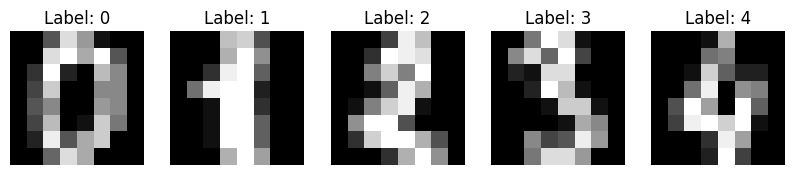

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.show()

## Apply K-Means
## K = 10 - Numbers 0 - 9
## Images grouped together based on pixel values

In [8]:
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(X)labels = np.zeros_like(clusters)

for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(y[mask], keepdims=True)[0]

clusters = kmeans.labels_

In [9]:
labels = np.zeros_like(clusters)

for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(y[mask], keepdims=True)[0]

## Accuracy to see how well the Clustering went

In [10]:
accuracy = accuracy_score(y, labels)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.86


## Cluster Centres

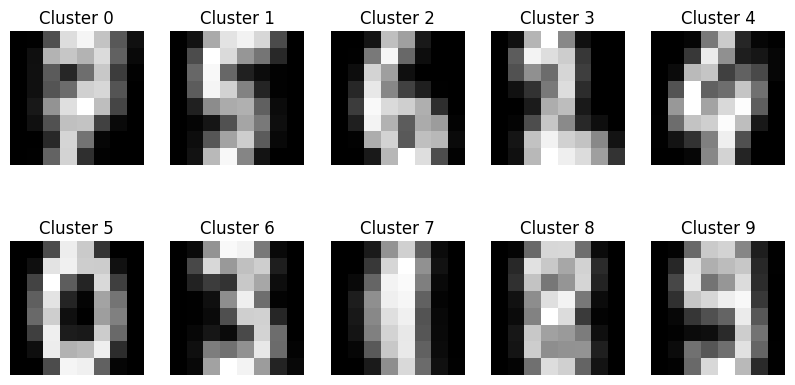

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(kmeans.cluster_centers_[i].reshape(8, 8), cmap='gray')
    ax.set_title(f"Cluster {i}")
    ax.axis('off')

plt.show()

## Confusion Matrix

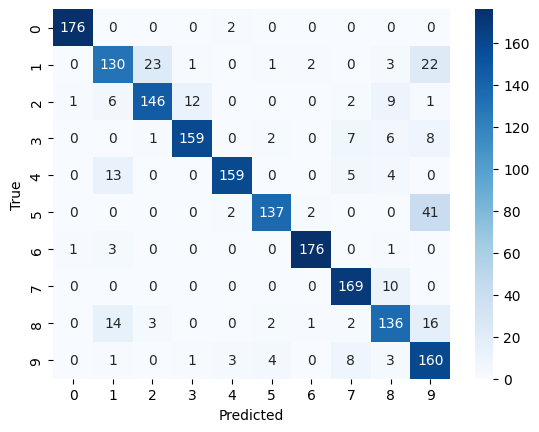

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y, labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

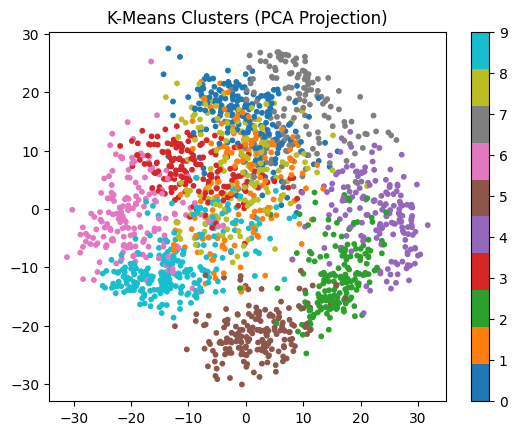

In [15]:
from sklearn.decomposition import PCA

pca = PCA(2)
X_reduced = pca.fit_transform(X)

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=clusters, cmap='tab10', s=10)
plt.colorbar()
plt.title("K-Means Clusters (PCA Projection)")
plt.show()